# CNN-Based Malaria Parasite Recognition in Human Blood Smear Images


In [ ]:
from google.colab import drive
import os

# 1. Mount the drive (Follow the popup instructions)
drive.mount('/content/drive')

# 2. This prints EVERY folder in your MyDrive. 
# Look for the one related to COMP472!
print("Folders found in your MyDrive:")
for folder in os.listdir('/content/drive/MyDrive'):
    print(f" - {folder}")

### Setup — Local (recommended) or Colab

**Collaborator workflow:**
1. Add the shared data folder to your Drive: open it → **Add shortcut to Drive** → place in **MyDrive** (not "Shared with me").
2. Clone the private repo on your local computer: `git clone https://github.com/iamBolu/COMP-472`
3. Open the repo in VS Code. Use the Colab extension, which will prompt you to connect to your Google Drive.
4. Click "Run All" to execute the notebook. All paths and setup will be handled automatically.

**Alternative (pure Colab):**
1. Upload this notebook to Colab, set **Hardware accelerator = GPU**
2. Add the shared data folder to your Drive as above.
3. Expected path: `MyDrive/COMP472/Project/data/raw`
4. Run cells top to bottom.


In [9]:
import sys, os, torch
from pathlib import Path

try:
    import google.colab
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    # Collaborators: "Add shortcut to Drive" -> place in MyDrive
    DRIVE_PROJECT_ROOT = "/content"
    data_candidates = [Path("/content/drive/MyDrive/COMP 472/Project/data/raw"),
                       Path("/content/drive/MyDrive/COMP472/Project/data/raw")]
    DATA_ROOT = next((p for p in data_candidates if p.exists()), data_candidates[0])
except ImportError:
    IN_COLAB = False
    DRIVE_PROJECT_ROOT = str(Path(os.getcwd()).parent) if Path(os.getcwd()).name == "notebooks" else os.getcwd()
    DATA_ROOT = Path(DRIVE_PROJECT_ROOT) / "data" / "raw"

sys.path.insert(0, DRIVE_PROJECT_ROOT)
os.chdir(DRIVE_PROJECT_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Runtime : {'Colab' if IN_COLAB else 'Local'}  |  Device: {device}")
print(f"Code: {DRIVE_PROJECT_ROOT}")
print(f"Data: {DATA_ROOT}  (exists: {DATA_ROOT.exists()})")

MessageError: [dfs_ephemeral] Credentials propagation unsuccessful

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Member 1: Data Visualization & Reporting

### Phase A
- Bar chart: class distribution per dataset
- Image grid: random samples per class
- Summary table: dataset sizes, class counts, imbalance
- **Define plotting functions:**
  1. `plot_training_curves(history, title)` — expects a `history` dict with keys: `"train_loss"`, `"val_loss"`, `"train_acc"`, `"val_acc"` (all lists, one value per epoch)
  2. `plot_confusion_matrix(labels, preds, class_names, title)` — expects `labels` and `preds` as numpy arrays, `class_names` as a list
  3. `print_classification_report(labels, preds, class_names)` — expects `labels` and `preds` as numpy arrays, `class_names` as a list


### **IMPORTANT: Output Format Contract for Members 3, 4, 5**

To ensure compatibility, all training results **must** be provided in the following format:

#### For each architecture (ResNet-18, VGG-16, MobileNet-V2) and each dataset:
```python
# Example for ResNet-18 (Member 3)
resnet_history = {}  # resnet_history["malaria"] = history dict (see below)
resnet_labels  = {}  # resnet_labels["malaria"]  = numpy array (test split)
resnet_preds   = {}  # resnet_preds["malaria"]   = numpy array (test split)

# Example for VGG-16 (Member 4)
vgg_history = {}
vgg_labels  = {}
vgg_preds   = {}

# Example for MobileNet-V2 (Member 5)
mobilenet_history = {}
mobilenet_labels  = {}
mobilenet_preds   = {}
```

#### The `history` dict **must** have:
```python
history = {
    "train_loss": [...],  # float per epoch
    "val_loss":   [...],
    "train_acc":  [...],  # float 0–1 per epoch
    "val_acc":    [...],
}
```

#### For Transfer Learning (Member 5, one dataset only):
```python
tl_freeze_history,  tl_freeze_labels,  tl_freeze_preds   = {...}, {...}, {...}
tl_finetune_history, tl_finetune_labels, tl_finetune_preds = {...}, {...}, {...}
```
- All dicts are keyed by dataset name (e.g. `"malaria"`)
- All arrays are numpy arrays (test split only)

---

### Example usage in Member 1 Phase B
```python
# For each model/dataset:
plot_training_curves(resnet_history["malaria"], "ResNet-18 Malaria")
plot_confusion_matrix(resnet_labels["malaria"], resnet_preds["malaria"], class_names, "ResNet-18 Malaria Confusion Matrix")
print_classification_report(resnet_labels["malaria"], resnet_preds["malaria"], class_names)
# ...repeat for VGG-16, MobileNet-V2, TL runs
```
---


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

DATASETS = {
    "malaria": os.path.join(DATA_ROOT, "malaria"),
    "iml_malaria": os.path.join(DATA_ROOT, "iml_malaria"),
    "miracle9to9": os.path.join(DATA_ROOT, "miracle9to9"),
}

def get_class_names(dataset_path, split):
    split_path = os.path.join(dataset_path, split)
    return sorted([
        name for name in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, name))
    ])

def list_valid_images(folder):
    return sorted([
        name for name in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, name))
        and os.path.splitext(name)[1].lower() in VALID_EXTENSIONS
    ])

def count_images_by_split(dataset_path):
    rows = []
    for split in ["train", "val", "test"]:
        for class_name in get_class_names(dataset_path, split):
            class_path = os.path.join(dataset_path, split, class_name)
            rows.append({
                "split": split,
                "class_name": class_name,
                "image_count": len(list_valid_images(class_path))
            })
    return pd.DataFrame(rows)

def build_phase_a_table(datasets):
    frames = []
    for dataset_name, dataset_path in datasets.items():
        df = count_images_by_split(dataset_path).copy()
        df["dataset"] = dataset_name
        frames.append(df[["dataset", "split", "class_name", "image_count"]])
    return pd.concat(frames, ignore_index=True)

def sample_image_sizes(dataset_path, max_per_class=20):
    rows = []
    for split in ["train", "val", "test"]:
        for class_name in get_class_names(dataset_path, split):
            class_path = os.path.join(dataset_path, split, class_name)
            image_files = list_valid_images(class_path)
            sample_files = image_files[:max_per_class]
            for image_file in sample_files:
                image_path = os.path.join(class_path, image_file)
                with Image.open(image_path) as img:
                    width, height = img.size
                rows.append({
                    "split": split,
                    "class_name": class_name,
                    "width": width,
                    "height": height
                })
    return pd.DataFrame(rows)

def plot_class_distribution(phase_a_df, dataset_name):
    subset = phase_a_df[phase_a_df["dataset"] == dataset_name]
    pivot_df = (
        subset.pivot(index="class_name", columns="split", values="image_count")
        .fillna(0)
        .reindex(sorted(subset["class_name"].unique()))
    )
    pivot_df.plot(kind="bar", figsize=(10, 5))
    plt.title(f"{dataset_name} class distribution by split")
    plt.xlabel("Class")
    plt.ylabel("Image count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_split_totals(split_totals_df):
    pivot_df = (
        split_totals_df.pivot(index="dataset", columns="split", values="image_count")
        .fillna(0)
        .reindex(sorted(split_totals_df["dataset"].unique()))
    )
    pivot_df.plot(kind="bar", figsize=(10, 5))
    plt.title("Split totals by dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Image count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_dataset_totals(dataset_totals_df):
    plt.figure(figsize=(8, 5))
    plt.bar(dataset_totals_df["dataset"], dataset_totals_df["image_count"])
    plt.title("Total images per dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Image count")
    plt.tight_layout()
    plt.show()

def plot_training_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def print_classification_report(labels, preds, class_names):
    report = classification_report(labels, preds, target_names=class_names)
    print(report)

def show_sample_images(dataset_path, split="train", samples_per_class=2):
    class_names = get_class_names(dataset_path, split)
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(4 * samples_per_class, 4 * len(class_names)))

    if len(class_names) == 1:
        axes = np.array([axes])
    if samples_per_class == 1:
        axes = axes.reshape(len(class_names), 1)

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, split, class_name)
        image_files = list_valid_images(class_path)[:samples_per_class]

        for j in range(samples_per_class):
            ax = axes[i, j]
            if j < len(image_files):
                image_path = os.path.join(class_path, image_files[j])
                with Image.open(image_path) as img:
                    ax.imshow(img)
                ax.set_title(f"{class_name}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name}")
    for split in ["train", "val", "test"]:
        split_path = os.path.join(dataset_path, split)
        print(split, "exists:", os.path.exists(split_path), "->", os.listdir(split_path))


malaria
train exists: True -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
val exists: True -> ['.DS_Store', 'gametocyte', 'ring', 'schizont', 'trophozoite']
test exists: True -> ['gametocyte', 'ring', 'schizont', 'trophozoite']

iml_malaria
train exists: True -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
val exists: True -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
test exists: True -> ['gametocyte', 'ring', 'schizont', 'trophozoite']

miracle9to9
train exists: True -> ['.DS_Store', 'Parasitized', 'Uninfected']
val exists: True -> ['.DS_Store', 'Parasitized', 'Uninfected']
test exists: True -> ['.DS_Store', 'Parasitized', 'Uninfected']


In [ ]:
def get_class_names(dataset_path, split):
    split_path = os.path.join(dataset_path, split)
    return sorted([
        name for name in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, name))
    ])

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name}")
    for split in ["train", "val", "test"]:
        print(split, "->", get_class_names(dataset_path, split))


malaria
train -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
val -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
test -> ['gametocyte', 'ring', 'schizont', 'trophozoite']

iml_malaria
train -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
val -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
test -> ['gametocyte', 'ring', 'schizont', 'trophozoite']

miracle9to9
train -> ['Parasitized', 'Uninfected']
val -> ['Parasitized', 'Uninfected']
test -> ['Parasitized', 'Uninfected']


In [ ]:

def list_valid_images(folder):
    return sorted([
        name for name in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, name))
        and os.path.splitext(name)[1].lower() in VALID_EXTENSIONS
    ])

example_folder = os.path.join(DATASETS["malaria"], "train", "gametocyte")
print("Example folder:", example_folder)
print("Number of valid images:", len(list_valid_images(example_folder)))
print("First 5 files:", list_valid_images(example_folder)[:5])

Example folder: c:\Users\isach\Downloads\UNI\5th year\2-Winter 2026\COM472-AI\Project\code\COMP-472\data\raw\malaria\train\gametocyte
Number of valid images: 49
First 5 files: ['027ab174-e47a-44f8-b85b-372449eeb7d8.png', '04c07425-57c7-415c-a0bc-36857bbd4049.png', '089c9744-f906-41d8-908d-1e37919a8658.png', '14005767-9296-4b48-8a9d-bbe9b2040005.png', '24879caf-a327-464c-9cd9-e0f3d9161079.png']


In [ ]:
sample_image_path = os.path.join(example_folder, list_valid_images(example_folder)[0])

with Image.open(sample_image_path) as img:
    print("Sample image path:", sample_image_path)
    print("Image size:", img.size)
    print("Image mode:", img.mode)

Sample image path: c:\Users\isach\Downloads\UNI\5th year\2-Winter 2026\COM472-AI\Project\code\COMP-472\data\raw\malaria\train\gametocyte\027ab174-e47a-44f8-b85b-372449eeb7d8.png
Image size: (1600, 1200)
Image mode: RGB


In [ ]:
def count_images_by_split(dataset_path):
    rows = []
    for split in ["train", "val", "test"]:
        for class_name in get_class_names(dataset_path, split):
            class_path = os.path.join(dataset_path, split, class_name)
            rows.append({
                "split": split,
                "class_name": class_name,
                "image_count": len(list_valid_images(class_path))
            })
    return pd.DataFrame(rows)

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name}")
    display(count_images_by_split(dataset_path))


malaria


,split,class_name,image_count
0,train,gametocyte,49
1,train,ring,108
2,train,schizont,88
3,train,trophozoite,326
4,val,gametocyte,4
5,val,ring,16
6,val,schizont,17
7,val,trophozoite,64
8,test,gametocyte,3
9,test,ring,45



iml_malaria


,split,class_name,image_count
0,train,gametocyte,81
1,train,ring,41
2,train,schizont,11
3,train,trophozoite,21
4,val,gametocyte,16
5,val,ring,8
6,val,schizont,2
7,val,trophozoite,4
8,test,gametocyte,13
9,test,ring,7



miracle9to9


,split,class_name,image_count
0,train,Parasitized,11713
1,train,Uninfected,11712
2,val,Parasitized,2066
3,val,Uninfected,2067
4,test,Parasitized,7952
5,test,Uninfected,7880


In [ ]:
def build_phase_a_table(datasets):
    frames = []
    for dataset_name, dataset_path in datasets.items():
        df = count_images_by_split(dataset_path).copy()
        df["dataset"] = dataset_name
        frames.append(df[["dataset", "split", "class_name", "image_count"]])
    return pd.concat(frames, ignore_index=True)

phase_a_df = build_phase_a_table(DATASETS)
phase_a_df

,dataset,split,class_name,image_count
0,malaria,train,gametocyte,49
1,malaria,train,ring,108
2,malaria,train,schizont,88
3,malaria,train,trophozoite,326
4,malaria,val,gametocyte,4
5,malaria,val,ring,16
6,malaria,val,schizont,17
7,malaria,val,trophozoite,64
8,malaria,test,gametocyte,3
9,malaria,test,ring,45


In [ ]:

split_totals_df = (
    phase_a_df.groupby(["dataset", "split"], as_index=False)["image_count"]
    .sum()
    .sort_values(["dataset", "split"])
    .reset_index(drop=True)
)

split_totals_df

,dataset,split,image_count
0,iml_malaria,test,25
1,iml_malaria,train,154
2,iml_malaria,val,30
3,malaria,test,94
4,malaria,train,571
5,malaria,val,101
6,miracle9to9,test,15832
7,miracle9to9,train,23425
8,miracle9to9,val,4133


In [ ]:

dataset_totals_df = (
    phase_a_df.groupby("dataset", as_index=False)["image_count"]
    .sum()
    .sort_values("dataset")
    .reset_index(drop=True)
)

dataset_totals_df

,dataset,image_count
0,iml_malaria,209
1,malaria,766
2,miracle9to9,43390


In [ ]:
def sample_image_sizes(dataset_path, max_per_class=20):
    rows = []
    for split in ["train", "val", "test"]:
        for class_name in get_class_names(dataset_path, split):
            class_path = os.path.join(dataset_path, split, class_name)
            image_files = list_valid_images(class_path)
            sample_files = image_files[:max_per_class]
            for image_file in sample_files:
                image_path = os.path.join(class_path, image_file)
                with Image.open(image_path) as img:
                    width, height = img.size
                rows.append({
                    "split": split,
                    "class_name": class_name,
                    "width": width,
                    "height": height
                })
    return pd.DataFrame(rows)

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name}")
    display(sample_image_sizes(dataset_path).head())


malaria


,split,class_name,width,height
0,train,gametocyte,1600,1200
1,train,gametocyte,1600,1200
2,train,gametocyte,1600,1200
3,train,gametocyte,1600,1200
4,train,gametocyte,1600,1200



iml_malaria


,split,class_name,width,height
0,train,gametocyte,1280,960
1,train,gametocyte,1280,960
2,train,gametocyte,1280,960
3,train,gametocyte,1280,960
4,train,gametocyte,1280,960



miracle9to9


,split,class_name,width,height
0,train,Parasitized,142,148
1,train,Parasitized,148,208
2,train,Parasitized,145,154
3,train,Parasitized,133,154
4,train,Parasitized,169,145


In [ ]:
image_size_summary_df = []

for dataset_name, dataset_path in DATASETS.items():
    size_df = sample_image_sizes(dataset_path, max_per_class=20)
    image_size_summary_df.append({
        "dataset": dataset_name,
        "sampled_images": len(size_df),
        "mean_width": round(size_df["width"].mean(), 2),
        "mean_height": round(size_df["height"].mean(), 2),
        "min_width": int(size_df["width"].min()),
        "max_width": int(size_df["width"].max()),
        "min_height": int(size_df["height"].min()),
        "max_height": int(size_df["height"].max())
    })

image_size_summary_df = pd.DataFrame(image_size_summary_df)
image_size_summary_df

,dataset,sampled_images,mean_width,mean_height,min_width,max_width,min_height,max_height
0,malaria,188,1693.32,1249.64,1600,1944,1200,1383
1,iml_malaria,126,1280.00,960.00,1280,1280,960,960
2,miracle9to9,120,141.80,144.75,100,208,97,208


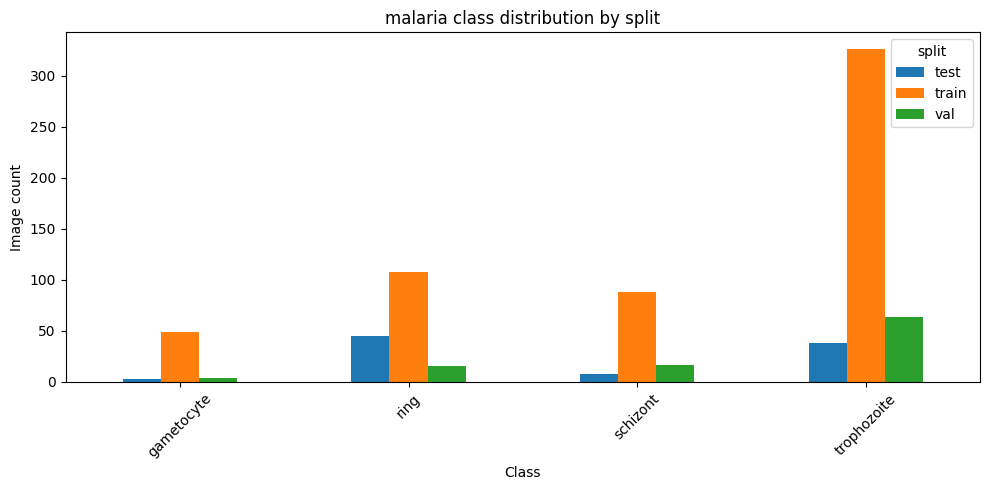

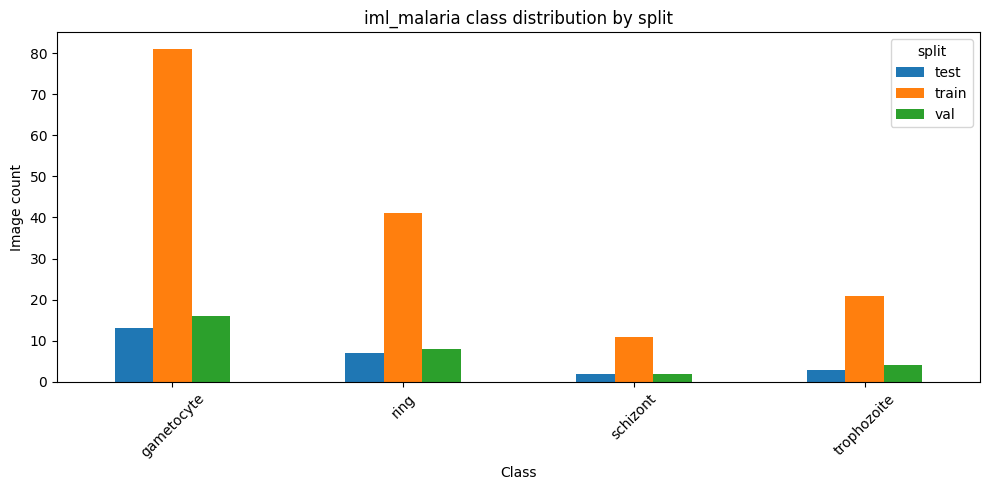

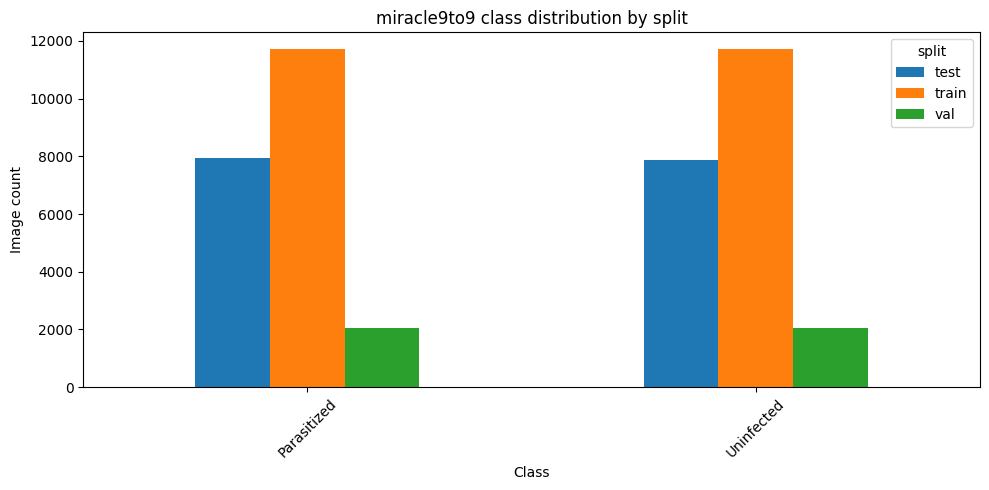

In [ ]:

for dataset_name in DATASETS:
    plot_class_distribution(phase_a_df, dataset_name)

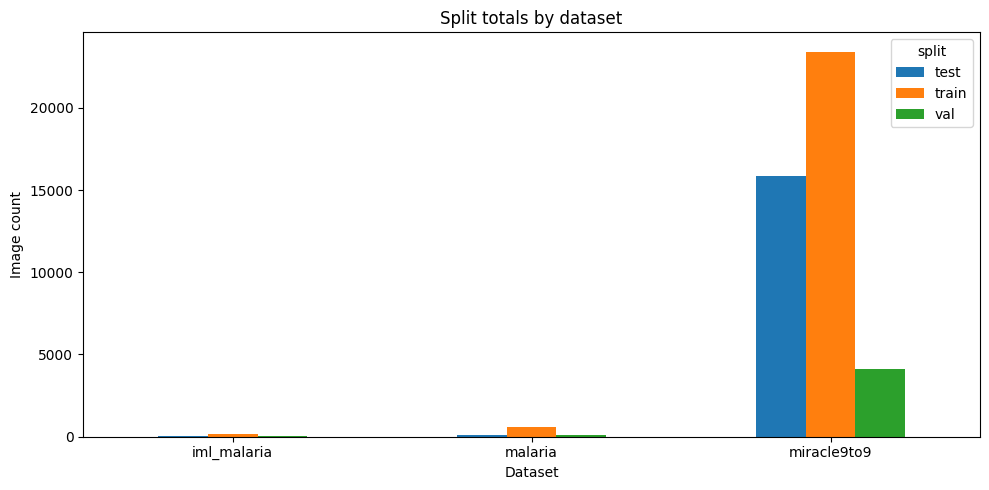

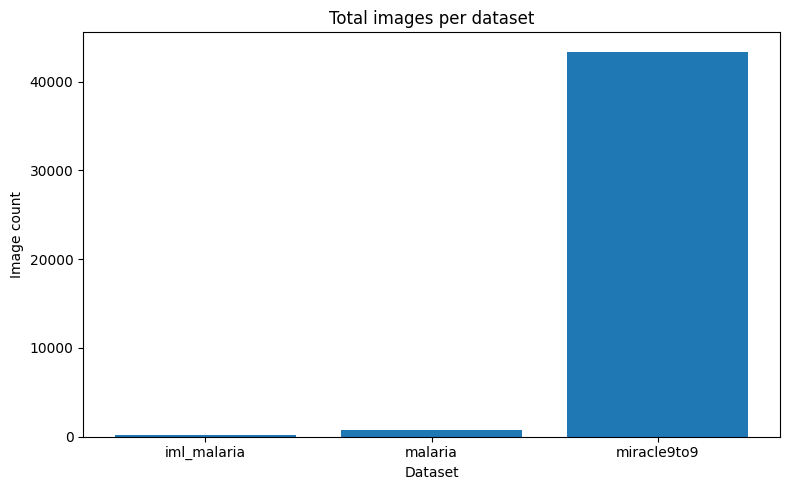

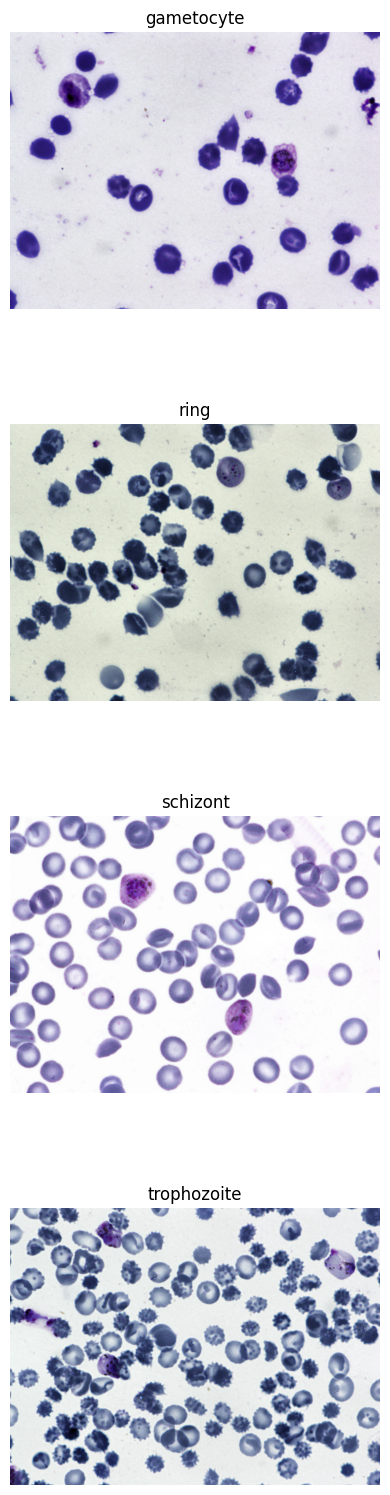

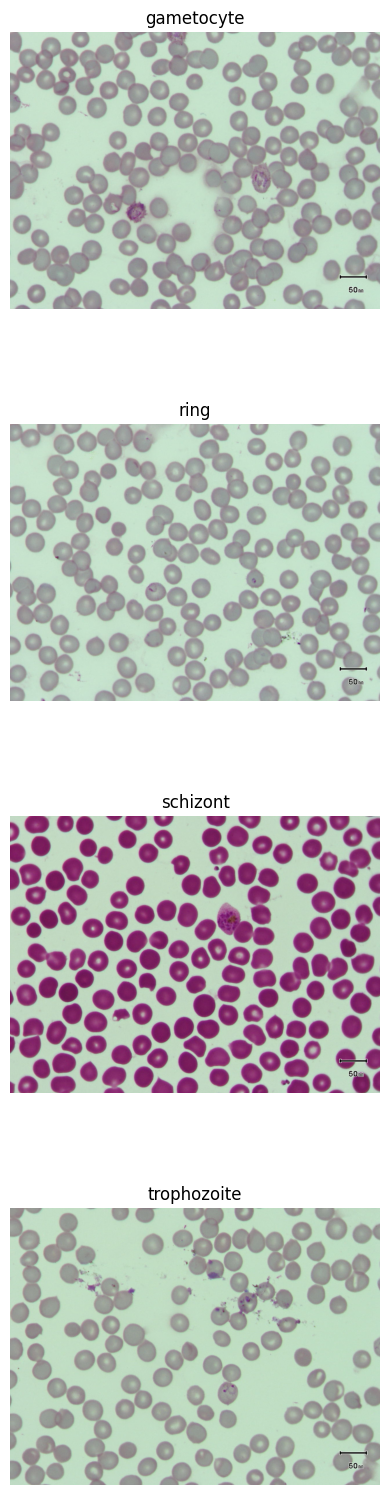

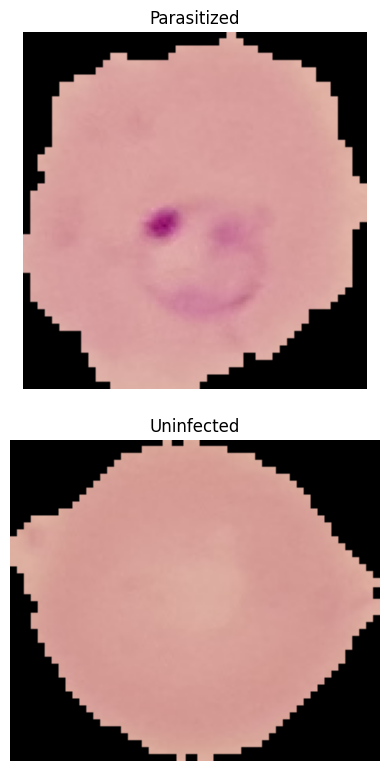

In [ ]:
plot_split_totals(split_totals_df)
plot_dataset_totals(dataset_totals_df)

show_sample_images(DATASETS["malaria"], split="train", samples_per_class=1)
show_sample_images(DATASETS["iml_malaria"], split="train", samples_per_class=1)
show_sample_images(DATASETS["miracle9to9"], split="train", samples_per_class=1)

,dataset,split,class_name,image_count
0,malaria,train,gametocyte,49
1,malaria,train,ring,108
2,malaria,train,schizont,88
3,malaria,train,trophozoite,326
4,malaria,val,gametocyte,4
5,malaria,val,ring,16
6,malaria,val,schizont,17
7,malaria,val,trophozoite,64
8,malaria,test,gametocyte,3
9,malaria,test,ring,45


,dataset,split,image_count
0,iml_malaria,test,25
1,iml_malaria,train,154
2,iml_malaria,val,30
3,malaria,test,94
4,malaria,train,571
5,malaria,val,101
6,miracle9to9,test,15832
7,miracle9to9,train,23425
8,miracle9to9,val,4133


,dataset,image_count
0,iml_malaria,209
1,malaria,766
2,miracle9to9,43390


,dataset,sampled_images,mean_width,mean_height,min_width,max_width,min_height,max_height
0,malaria,188,1693.32,1249.64,1600,1944,1200,1383
1,iml_malaria,126,1280.00,960.00,1280,1280,960,960
2,miracle9to9,120,141.80,144.75,100,208,97,208


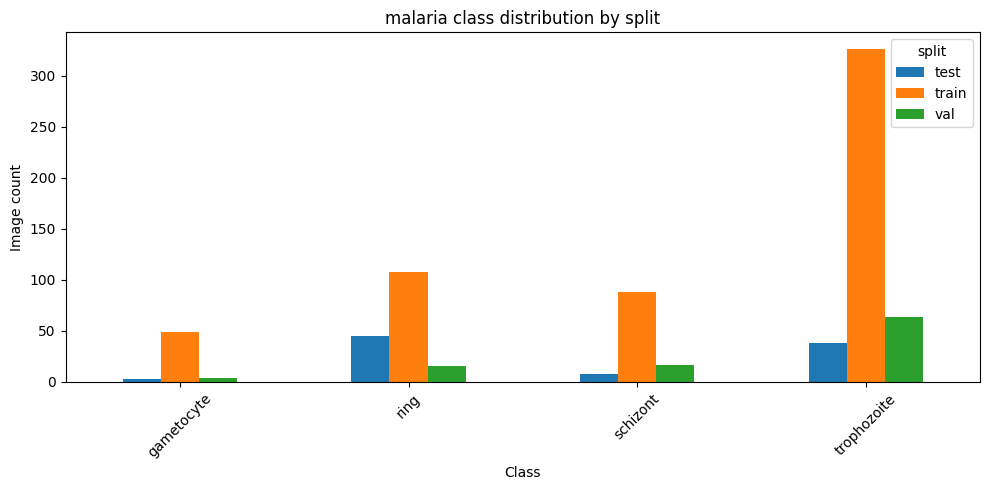

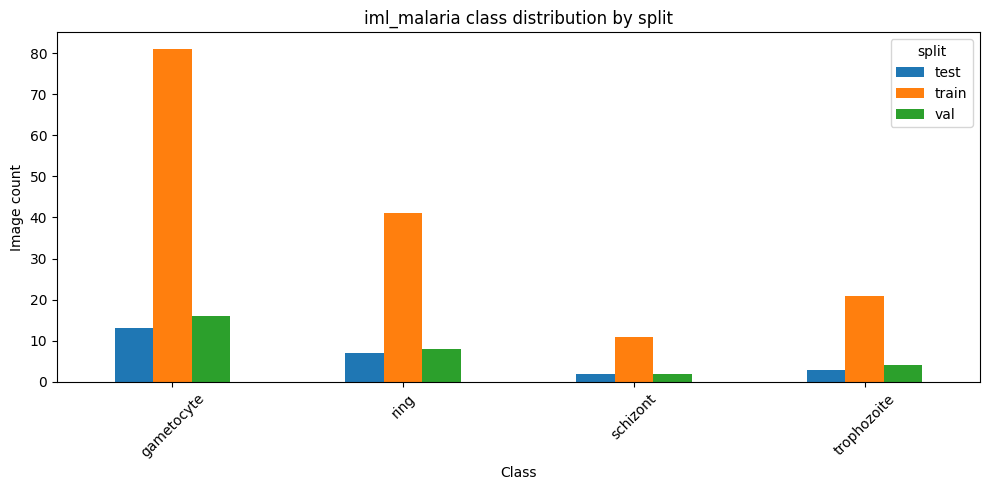

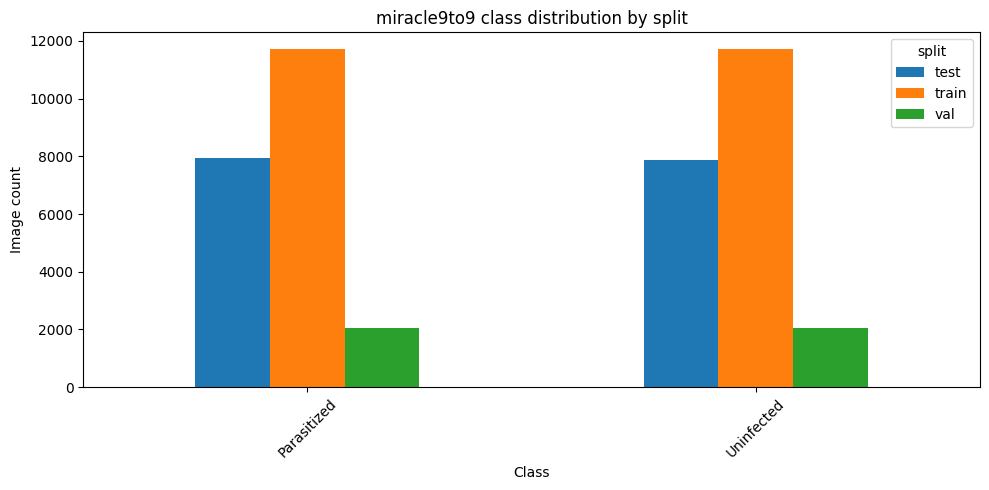

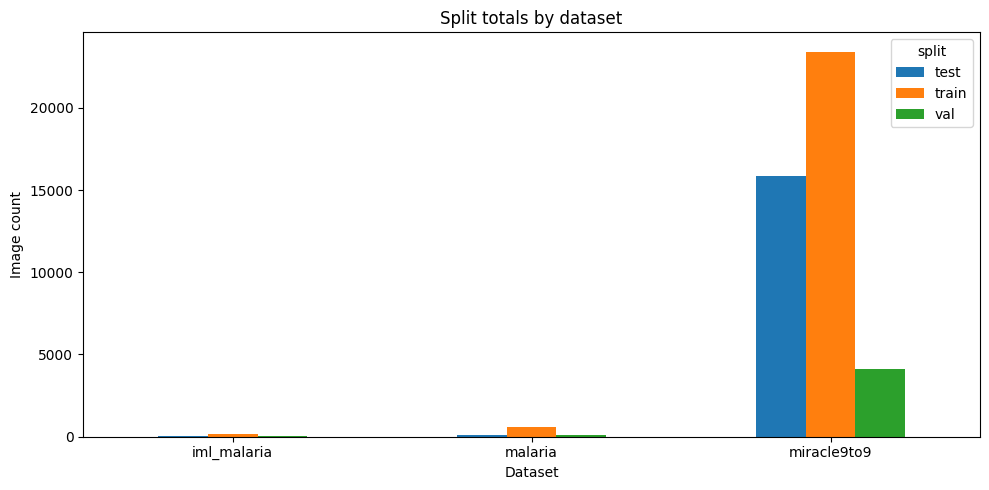

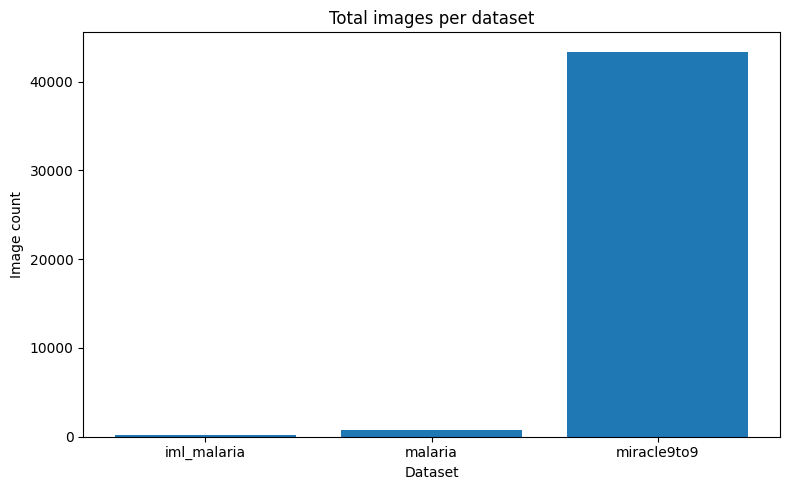

In [ ]:
phase_a_df = build_phase_a_table(DATASETS)
split_totals_df = (
    phase_a_df.groupby(["dataset", "split"], as_index=False)["image_count"]
    .sum()
    .sort_values(["dataset", "split"])
    .reset_index(drop=True)
)
dataset_totals_df = (
    phase_a_df.groupby("dataset", as_index=False)["image_count"]
    .sum()
    .sort_values("dataset")
    .reset_index(drop=True)
)

image_size_summary_df = []
for dataset_name, dataset_path in DATASETS.items():
    size_df = sample_image_sizes(dataset_path, max_per_class=20)
    image_size_summary_df.append({
        "dataset": dataset_name,
        "sampled_images": len(size_df),
        "mean_width": round(size_df["width"].mean(), 2),
        "mean_height": round(size_df["height"].mean(), 2),
        "min_width": int(size_df["width"].min()),
        "max_width": int(size_df["width"].max()),
        "min_height": int(size_df["height"].min()),
        "max_height": int(size_df["height"].max())
    })
image_size_summary_df = pd.DataFrame(image_size_summary_df)

display(phase_a_df)
display(split_totals_df)
display(dataset_totals_df)
display(image_size_summary_df)

for dataset_name in DATASETS:
    plot_class_distribution(phase_a_df, dataset_name)

plot_split_totals(split_totals_df)
plot_dataset_totals(dataset_totals_df)

# Phase A Summary
The dataset root path was verified and all three datasets were confirmed to be accessible from Google Drive. The directory structure for each dataset was checked, including the train, validation, and test splits and their class subfolders. Non-image noise files such as .DS_Store were detected in some folders, so only valid image files were counted.

Clean image counts were computed per class and split for malaria, iml_malaria, and miracle9to9. Summary tables were created for class counts, split totals, dataset totals, and sampled image-size statistics. Sample images were also opened successfully, confirming that the paths and files are valid.

The Phase A results show that miracle9to9 is the largest dataset and is relatively balanced, malaria is smaller and imbalanced across classes, and iml_malaria is the smallest and most imbalanced. The sampled image-size analysis also shows that iml_malaria is size-consistent, while miracle9to9 has more variation.

---
## Member 2: Pipeline Implementation

**Goal:**
- Make loading and using data easy for all members.
- Check data quality and organize all images.
- Apply the same image transforms for fair model comparison.
- Build one system to get DataLoaders for any dataset and split.
- All models use this pipeline to get their training, validation, and test data.

**Advantages**
- All members gets the same data splits and transforms.
- Makes results fair and easy to compare.
- Simple to add new datasets or change batch size.
- Shared code means fewer bugs and less confusion.


### Step 1 - Imports & Constants


In [ ]:
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# DATA_ROOT and device are set in cell 3 based on runtime
IMAGE_INPUT_SIZE = 128
BATCH_SIZE       = 32
NUM_WORKERS      = 0
DATASET_NAMES    = ["miracle9to9", "malaria", "iml_malaria"]
IMAGE_EXTENSIONS = {".jpg", ".png"}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"Exists:    {DATA_ROOT.exists()}")


DATA_ROOT: c:\Users\isach\Downloads\UNI\5th year\2-Winter 2026\COM472-AI\Project\code\COMP-472\data\raw
Exists:    True


### Step 2 - Data Inventory

Scan all images under `data/raw/` and report class distribution and imbalance ratios per dataset/split.
PIL validation is skipped — `broken_files_report.txt` (notebooks/) was generated in a prior run.


In [ ]:
all_image_paths = pd.Series([
    path for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
])

if all_image_paths.empty:
    raise FileNotFoundError(f"No images found under '{DATA_ROOT.resolve()}'. Expected: data/raw/<dataset>/<split>/<class>/image.ext")

valid_images_inventory_df = pd.DataFrame({
    "dataset":   all_image_paths.map(lambda p: p.relative_to(DATA_ROOT).parts[0]),
    "split":     all_image_paths.map(lambda p: p.relative_to(DATA_ROOT).parts[1]),
    "class_raw": all_image_paths.map(lambda p: p.parent.name),
    "filepath":  all_image_paths,
})
print(f"Total images: {len(valid_images_inventory_df)}")

class_distribution_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split", "class_raw"])
    .size()
    .reset_index(name="image_count")
)
print("\nClass distribution:")
print(class_distribution_df.to_string(index=False))

split_totals_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split"])
    .size()
    .reset_index(name="total_images")
)
print("\nSplit totals:")
print(split_totals_df.to_string(index=False))

imbalance_df = (
    class_distribution_df
    .groupby(["dataset", "split"])["image_count"]
    .agg(max_count="max", min_count="min")
    .assign(imbalance_ratio=lambda df: (df["max_count"] / df["min_count"]).round(2))
    .reset_index()
)
print("\nImbalance ratios (max / min class count):")
print(imbalance_df.to_string(index=False))


Total images: 44365

Class distribution:
    dataset split   class_raw  image_count
iml_malaria  test  gametocyte           13
iml_malaria  test        ring            7
iml_malaria  test    schizont            2
iml_malaria  test trophozoite            3
iml_malaria train  gametocyte           81
iml_malaria train        ring           41
iml_malaria train    schizont           11
iml_malaria train trophozoite           21
iml_malaria   val  gametocyte           16
iml_malaria   val        ring            8
iml_malaria   val    schizont            2
iml_malaria   val trophozoite            4
    malaria  test  gametocyte            3
    malaria  test        ring           45
    malaria  test    schizont            8
    malaria  test trophozoite           38
    malaria train  gametocyte           49
    malaria train        ring          108
    malaria train    schizont           88
    malaria train trophozoite          326
    malaria   val  gametocyte            4
    malaria  

### Step 3 - Transform Policy

One shared policy for all 9 baseline training runs.  
- `training_transforms` : resize → geometric augmentation → color jitter → normalize  
- `evaluation_transforms` : resize → normalize only (no augmentation on val/test)


In [ ]:
training_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

evaluation_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("training_transforms :")
print(training_transforms)
print("\nevaluation_transforms :")
print(evaluation_transforms)


training_transforms :
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

evaluation_transforms :
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### Step 4 - MalariaDataset

Custom `Dataset` that works for all three datasets.  
Accepts a pre-filtered `split_inventory_df` slice from `valid_images_inventory_df` (Step 2), so only validated images are ever loaded.  
Handles `orvile`'s duplicate training folders (`"gametocyte 2"` → `"gametocyte"`) by stripping the trailing numeric suffix via vectorized regex on class folder names.


In [ ]:
class MalariaDataset(Dataset):
    def __init__(self, split_inventory_df, transform=None):
        normalized_class_names = split_inventory_df["class_raw"].str.replace(r"\s+\d+$", "", regex=True)

        unique_classes   = sorted(normalized_class_names.unique())
        class_to_index   = {class_name: index for index, class_name in enumerate(unique_classes)}

        self.image_paths  = split_inventory_df["filepath"].to_numpy()
        self.labels       = normalized_class_names.map(class_to_index).to_numpy()
        self.class_names  = unique_classes
        self.class_to_idx = class_to_index
        self.transform    = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(self.labels[index])


### Step 5 - Datasets & DataLoaders

`datasets_registry[dataset_name][split]` → `MalariaDataset`  
`dataloaders_registry[dataset_name][split]` → `DataLoader` ready for training  

All 9 scratch models and 2 transfer learning models consume `dataloaders_registry`.


In [ ]:
SPLIT_TRANSFORMS = {"train": training_transforms, "val": evaluation_transforms, "test": evaluation_transforms}

datasets_registry = {
    dataset_name: {
        split: MalariaDataset(
            valid_images_inventory_df[
                (valid_images_inventory_df["dataset"] == dataset_name) &
                (valid_images_inventory_df["split"]   == split)
            ].reset_index(drop=True),
            transform=split_transform,
        )
        for split, split_transform in SPLIT_TRANSFORMS.items()
    }
    for dataset_name in DATASET_NAMES
}

dataloaders_registry = {
    dataset_name: {
        split: DataLoader(
            dataset,
            batch_size  = BATCH_SIZE,
            shuffle     = (split == "train"),
            num_workers = NUM_WORKERS,
            pin_memory  = torch.cuda.is_available(),
            drop_last   = (split == "train"),
        )
        for split, dataset in split_datasets.items()
        if len(dataset) > 0
    }
    for dataset_name, split_datasets in datasets_registry.items()
}

for dataset_name, split_datasets in datasets_registry.items():
    for split_name, dataset in split_datasets.items():
        if len(dataset) == 0:
            print(f"{dataset_name:15s} | {split_name:5s} | SKIPPED since 0 valid images")
            continue
        num_batches = len(dataloaders_registry[dataset_name][split_name])
        print(f"{dataset_name:15s} | {split_name:5s} | {len(dataset):5d} images | {num_batches:3d} batches | classes: {dataset.class_names}")


miracle9to9     | train | 23425 images | 732 batches | classes: ['Parasitized', 'Uninfected']
miracle9to9     | val   |  4133 images | 130 batches | classes: ['Parasitized', 'Uninfected']
miracle9to9     | test  | 15832 images | 495 batches | classes: ['Parasitized', 'Uninfected']
malaria         | train |   571 images |  17 batches | classes: ['gametocyte', 'ring', 'schizont', 'trophozoite']
malaria         | val   |   101 images |   4 batches | classes: ['gametocyte', 'ring', 'schizont', 'trophozoite']
malaria         | test  |    94 images |   3 batches | classes: ['gametocyte', 'ring', 'schizont', 'trophozoite']
iml_malaria     | train |   154 images |   4 batches | classes: ['gametocyte', 'ring', 'schizont', 'trophozoite']
iml_malaria     | val   |    30 images |   1 batches | classes: ['gametocyte', 'ring', 'schizont', 'trophozoite']
iml_malaria     | test  |    25 images |   1 batches | classes: ['gametocyte', 'ring', 'schizont', 'trophozoite']


### Step 6 - Model Utilities

`build_model(arch, num_classes)` → ready-to-train ResNet-18, VGG-16, or MobileNet-V2 sent to `device`  
`count_parameters(model)` → total trainable parameters, printed as a comparison table  
`train_one_epoch(model, loader, criterion, optimizer, device)` → `(avg_loss, accuracy)` after one training pass  
`evaluate(model, loader, criterion, device)` → `(avg_loss, accuracy)` after one val/test pass  

All 9 scratch models and 2 transfer learning models call these shared utilities.


In [ ]:
import torch.nn as nn
from torchvision import models

# Step 6a: Reproducibility
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

ARCH_NAMES = ["resnet18", "vgg16", "mobilenet_v2"]


# Step 6b: build_model
def build_model(arch, num_classes):
    """Build a torchvision model from scratch with the final layer replaced."""
    if arch == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif arch == "vgg16":
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif arch == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown architecture: {arch}")
    return model.to(device)


# Step 6c: count_parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Print parameter comparison table
print(f"{'Architecture':<16} {'Parameters':>12}")
print("-" * 30)
for arch in ARCH_NAMES:
    m = build_model(arch, num_classes=4)
    print(f"{arch:<16} {count_parameters(m):>12,}")
    del m


# Step 6d: train_one_epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * images.size(0)
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


# Step 6e: evaluate
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss    += loss.item() * images.size(0)
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


print("\nMember 2 utilities ready: build_model, count_parameters, train_one_epoch, evaluate")

Architecture       Parameters
------------------------------
resnet18           11,178,564
vgg16             134,276,932
mobilenet_v2        2,228,996

Member 2 utilities ready: build_model, count_parameters, train_one_epoch, evaluate


### Member 2: Summary
- **MalariaDataset**
  - Loads and labels images for any dataset structure (requirement: flexible data handling).
  - All members use this to access images and class labels for training/testing.
- **dataloaders_registry**
  - Stores DataLoader objects for every dataset and split (requirement: unified batching).
  - Use this to get batches for training, validation, or testing in your code.
- **build_model(arch, num_classes)**
  - Creates ResNet-18, VGG-16, or MobileNet-V2 with correct output size (requirement: 3 CNNs, no custom models).
  - Call this to get a ready-to-train model for any dataset.
- **count_parameters(model)**
  - Counts all trainable parameters (requirement: compare model complexity).
  - Use this to print or report model size for your experiments.
- **train_one_epoch(model, loader, criterion, optimizer, device)**
  - Runs one training pass and returns average loss/accuracy (requirement: standard training loop).
  - Use this in your training loop for each epoch.
- **evaluate(model, loader, criterion, device)**
  - Runs evaluation (no gradient) and returns average loss/accuracy (requirement: standard evaluation).
  - Use this to check model performance on val/test sets.


---
## Member 3: Training Loop + ResNet-18

### Uses from Member 2 *(must be defined before running this section)*
- `build_model(arch, num_classes)` — instantiate ResNet-18 with `weights=None`
- `train_one_epoch(model, loader, criterion, optimizer, device)`
- `evaluate(model, loader, criterion, device)`

### New Coding Tasks (TO DO)
1. **`collect_predictions(model, loader, device)`** — returns `(labels, preds)` as **numpy arrays** over the full loader.
2. **`fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, checkpoint_path)`** — calls `train_one_epoch` + `evaluate` each epoch, saves best-val checkpoint, returns a `history` dict.
3. **Train ResNet-18 × 3** (miracle9to9, malaria, iml_malaria): `lr=0.001`, Adam, CrossEntropyLoss, `epochs=10`. Save checkpoints to `Path(DRIVE_PROJECT_ROOT) / "checkpoints"`.

### Output contract for Member 1 Phase B
`fit()` must return a dict with **exactly** these keys:
```python
history = {
    "train_loss": [...],  # float per epoch
    "val_loss":   [...],
    "train_acc":  [...],  # float 0–1 per epoch
    "val_acc":    [...],
}
```
After training, run `collect_predictions` on the **test** split and store results — Members 4 & 5 follow the same pattern:
```python
resnet_history = {}  # resnet_history["miracle9to9"] = history dict
resnet_labels  = {}  # resnet_labels["miracle9to9"]  = numpy array
resnet_preds   = {}  # resnet_preds["miracle9to9"]   = numpy array
```
Member 1's `plot_training_curves(history, title)`, `plot_confusion_matrix(labels, preds, class_names, title)`, and `print_classification_report(labels, preds, class_names)` will consume these directly.

### Hints
- `collect_predictions` → **Lab_Tutorial_Week_9.ipynb, line 1064**
- `fit` with history + checkpointing → **Lab_Tutorial_Week_9.ipynb, line 1136**
- `num_classes = len(datasets_registry[dataset_name]["train"].class_names)`
- No TensorFlow / Keras.

### Requirements Alignment
> *"train 9 different models... for fair comparison, all models should be trained under the same conditions (same hyperparameters)."* — Project Requirements

### Tasks for Final Report & Video
- Report val and test accuracy for each of the 3 ResNet-18 runs.


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def fit(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    """
    Generic training loop designed for Member 4 and 5 to use.
    - model: The CNN architecture (VGG, ResNet, etc.)
    - returns: 'history' dict required by member 1's plotting functions.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        history["train_loss"].append(train_loss/len(train_loader))
        history["train_acc"].append(100.*correct/total)
        history["val_loss"].append(val_loss/len(val_loader))
        history["val_acc"].append(100.*val_correct/val_total)
        
        print(f'Acc: {history["train_acc"][-1]:.2f}% | Val Acc: {history["val_acc"][-1]:.2f}%')
    return history

def collect_predictions(model, loader):
    """
    Evaluation tool for Confusion Matrices.
    - returns: (y_true, y_pred) as numpy arrays for Member 1's CM functions.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

In [1]:

# RESNET-18 EXPERIMENTS
# We run ResNet-18 across all datasets as assigned in the Plan
target_datasets = ["malaria", "iml_malaria", "miracle9to9"]
resnet_histories = {}

for ds_name in target_datasets:
    print(f"\n>>> TRAINING RESNET-18 ON: {ds_name} <<<")
    
    # 1. Get DataLoaders from Member 2's registry
    loaders = dataloaders_registry[ds_name]
    num_classes = len(datasets_registry[ds_name]['train'].classes)
    
    # 2. Build Model using Member 2's build_model function
    resnet_model = build_model("resnet18", num_classes=num_classes)
    
    # 3. Setup standard hyperparameters
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.001)
    
    # 4. Execute training using my fit() function
    history = fit(resnet_model, loaders['train'], loaders['val'], criterion, optimizer, epochs=5)
    resnet_histories[ds_name] = history
    
    # 5. TEST: Call Member 1's plotting functions to verify everything is linked
    plot_training_curves(history, title=f"ResNet-18 Progress: {ds_name}")
    
    y_true, y_pred = collect_predictions(resnet_model, loaders['test'])
    plot_confusion_matrix(y_true, y_pred, loaders['test'].dataset.classes, title=f"ResNet-18 Confusion Matrix: {ds_name}")


>>> TRAINING RESNET-18 ON: malaria <<<


NameError: name 'dataloaders_registry' is not defined

---
## Member 4: VGG-16 + Optimization

### Uses from Member 2 & 3 *(must be defined before running this section)*
- `build_model("vgg16", num_classes)` — from Member 2
- `train_one_epoch`, `evaluate` — from Member 2
- `fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, checkpoint_path)` — from Member 3
- `collect_predictions(model, loader, device)` — from Member 3

### New Coding Tasks (TO DO)
1. **Train VGG-16 × 3** (miracle9to9, malaria, iml_malaria): `lr=0.001`, Adam, CrossEntropyLoss, `epochs=10`.
2. **LR sweep** — on one dataset, train VGG-16 with `lr ∈ {0.01, 0.001, 0.0001}`. Log val accuracy per LR. Pick the best and explain why.

### Output contract for Member 1 Phase B
Follow the **same storage pattern** as Member 3:
```python
vgg_history = {}  # vgg_history["miracle9to9"] = history dict with train_loss/val_loss/train_acc/val_acc
vgg_labels  = {}  # vgg_labels["miracle9to9"]  = numpy array (test split)
vgg_preds   = {}  # vgg_preds["miracle9to9"]   = numpy array
```
Member 1's `plot_training_curves`, `plot_confusion_matrix`, and `print_classification_report` will consume these directly.

### Hints
- `build_model("vgg16", num_classes)` → **Lab_Tutorial_Week_8 (1).ipynb, line 152**
- LR sweep loop → **Lab_Tutorial_Week_9.ipynb, line ~1136**
- No TensorFlow / Keras.

### Requirements Alignment
> *"Each team should choose at least one of the 9 models trained from scratch and attempt to optimize it through hyperparameter tuning... only from: learning rate, batch size, and loss function."* — Project Requirements

### Tasks for Final Report & Video
- Report val and test accuracy for each of the 3 VGG-16 runs.
- Table: LR → val accuracy; justify the best LR choice.


---
## Member 5: MobileNet-V2 + Transfer Learning + T-SNE

### Uses from Member 2 & 3 *(must be defined before running this section)*
- `build_model("mobilenet_v2", num_classes)` — from Member 2
- `train_one_epoch`, `evaluate` — from Member 2
- `fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, checkpoint_path)` — from Member 3
- `collect_predictions(model, loader, device)` — from Member 3

### New Coding Tasks (TO DO)
1. **Train MobileNet-V2 × 3** (miracle9to9, malaria, iml_malaria): `lr=0.001`, Adam, CrossEntropyLoss, `epochs=10`.
2. **TL Run 1** (pick one dataset) — pretrained weights (`weights="IMAGENET1K_V1"`), freeze backbone, train head only for 10 epochs.
3. **TL Run 2** (same dataset) — unfreeze full network, fine-tune for 10 epochs from the frozen checkpoint.
4. **T-SNE** — for ≥4 models: replace classifier with `nn.Identity()`, extract test-set embeddings, `sklearn.manifold.TSNE(n_components=2)`, scatter plot coloured by class label.
5. **Final comparison table** — val accuracy, test accuracy, macro-F1 for all 11 models as a sorted DataFrame.

### Output contract for Member 1 Phase B
Follow the **same storage pattern** as Members 3 & 4:
```python
mobilenet_history  = {}  # mobilenet_history["miracle9to9"]  = history dict with train_loss/val_loss/train_acc/val_acc
mobilenet_labels   = {}  # mobilenet_labels["miracle9to9"]   = numpy array (test split)
mobilenet_preds    = {}  # mobilenet_preds["miracle9to9"]    = numpy array

# TL runs — store under the chosen dataset name with a descriptive key
tl_freeze_history,  tl_freeze_labels,  tl_freeze_preds   = {...}, {...}, {...}
tl_finetune_history, tl_finetune_labels, tl_finetune_preds = {...}, {...}, {...}
```
Member 1's `plot_training_curves`, `plot_confusion_matrix`, `print_classification_report` will consume all of these.

### Hints
- `build_model("mobilenet_v2", num_classes)` → **Lab_Tutorial_Week_8 (1).ipynb, line 152**
- `build_transfer_model()` (freeze backbone) → **Lab_Tutorial_Week_9.ipynb, line 7004**
- `fit_transfer_model()` → **Lab_Tutorial_Week_9.ipynb, line 7035**
- F1: `sklearn.metrics.f1_score(labels, preds, average="macro")`
- No TensorFlow / Keras.

### Requirements Alignment
> *"2 additional models using Transfer Learning (any 2 combinations of dataset+architecture)."* — Project Requirements  
> *"Use TSNE or Grad-CAM to visualize the performance of at least 4 different models."* — Project Requirements

### Tasks for Final Report & Video
- Compare scratch vs TL-freeze vs TL-fine-tune — table + discussion.
- T-SNE scatter plots in **Results & Discussion**.
- **Conclusion** — best model per dataset, key findings, limitations.
